# 04 — Capital Allocation

This notebook implements **Capital Allocation** from BKM Chapter 6:
how to optimally split your wealth between the risky portfolio and the risk-free asset.

**Key formula (BKM):**
$$y^* = \frac{E[r_P] - r_f}{A \cdot \sigma_P^2}$$

where:
- $y^*$ = optimal fraction in risky portfolio
- $A$ = investor's risk aversion coefficient
- $\sigma_P^2$ = variance of risky portfolio
- $E[r_P] - r_f$ = risk premium

**Contents:**
1. Sensitivity of y* to risk aversion A
2. Capital Allocation Line (CAL)
3. Complete Portfolio for different investor profiles
4. Black-Litterman: impact of views on optimal allocation
5. Interactive allocation table

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.optimizers.markowitz import maximum_sharpe, efficient_frontier
from src.estimators.returns import historical_mean, capm_returns, black_litterman_returns
from src.estimators.covariance import ledoit_wolf_covariance
from src.data_fetcher.fetcher import get_market_caps
from src.risk.metrics import optimal_risky_weight, capital_allocation_line
from config import *

returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)
cov = pd.read_csv('../data/cov_ledoit_wolf.csv', index_col=0)
mu  = historical_mean(returns)

# Use the Tangency Portfolio as risky asset
tp = maximum_sharpe(mu, cov, RISK_FREE_RATE_ANNUAL, MIN_WEIGHT, MAX_WEIGHT)
print(tp)


─────────────────────────────────────────────
  Strategy : Maximum Sharpe (Tangency)
  E[r]     : 10.28%
  σ        : 9.99%
  Sharpe   : 0.599
─────────────────────────────────────────────


## 1. Optimal y* for Different Risk Aversion Values

BKM shows that y* is inversely proportional to A. Let's visualize this.

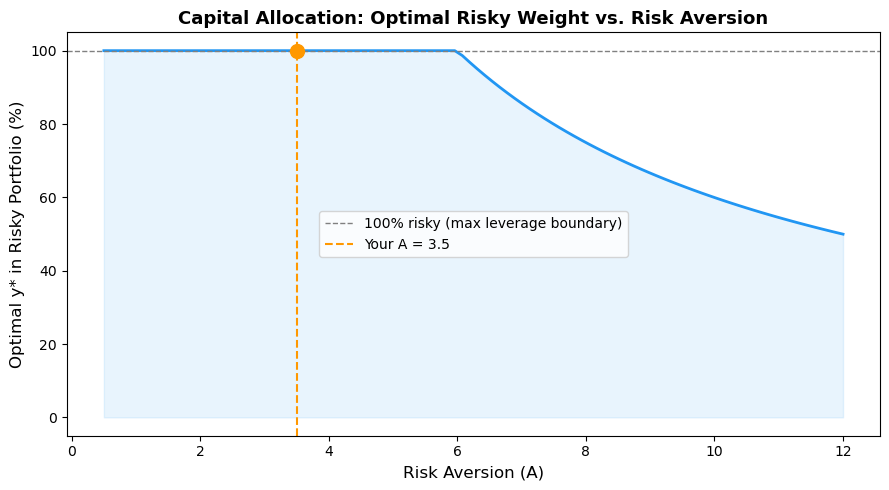


Your optimal y* (A=3.5): 100.0% in risky portfolio
                              0.0% in risk-free asset


In [2]:
A_values = np.linspace(0.5, 12, 100)
y_stars  = [optimal_risky_weight(tp.expected_return, tp.volatility, RISK_FREE_RATE_ANNUAL, A)
            for A in A_values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(A_values, np.array(y_stars)*100, lw=2, color='#2196F3')
ax.axhline(100, color='gray', ls='--', lw=1, label='100% risky (max leverage boundary)')
ax.axvline(RISK_AVERSION, color='#FF9800', ls='--', lw=1.5, label=f'Your A = {RISK_AVERSION}')
ax.scatter([RISK_AVERSION], [optimal_risky_weight(tp.expected_return, tp.volatility,
           RISK_FREE_RATE_ANNUAL, RISK_AVERSION)*100],
           color='#FF9800', s=100, zorder=5)
ax.fill_between(A_values, np.array(y_stars)*100, 0, alpha=0.1, color='#2196F3')
ax.set_xlabel('Risk Aversion (A)', fontsize=12)
ax.set_ylabel('Optimal y* in Risky Portfolio (%)', fontsize=12)
ax.set_title('Capital Allocation: Optimal Risky Weight vs. Risk Aversion', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../results/04_y_star.png', dpi=150)
plt.show()

y_opt = optimal_risky_weight(tp.expected_return, tp.volatility, RISK_FREE_RATE_ANNUAL, RISK_AVERSION)
print(f'\nYour optimal y* (A={RISK_AVERSION}): {y_opt*100:.1f}% in risky portfolio')
print(f'                              {(1-y_opt)*100:.1f}% in risk-free asset')

## 2. Capital Allocation Line (CAL)

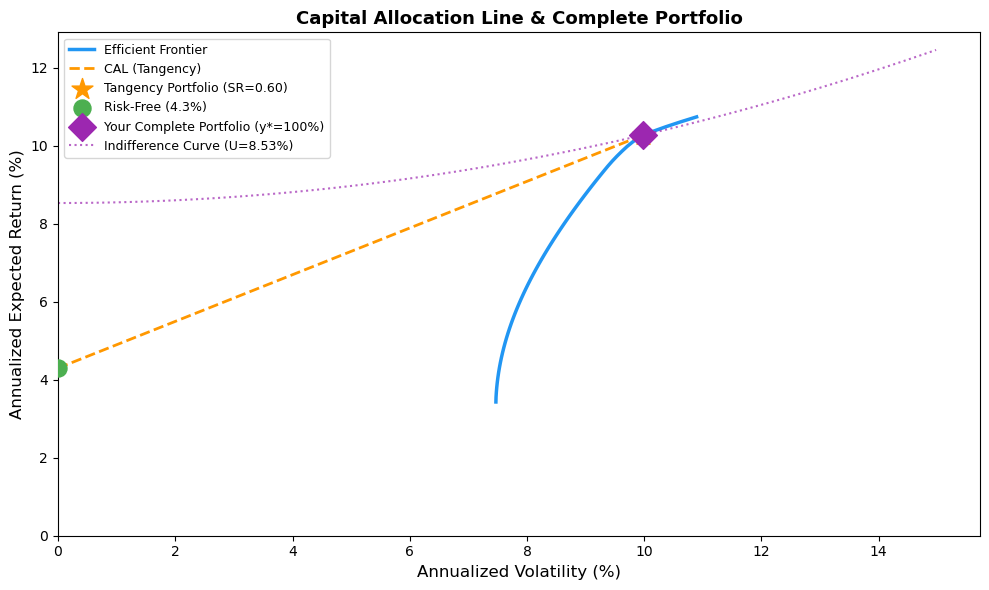

In [3]:
cal = capital_allocation_line(tp.expected_return, tp.volatility, RISK_FREE_RATE_ANNUAL)

# Get the efficient frontier too
frontier = efficient_frontier(mu, cov, RISK_FREE_RATE_ANNUAL, 80, MIN_WEIGHT, MAX_WEIGHT)

fig, ax = plt.subplots(figsize=(10, 6))

# Frontier
ax.plot(frontier['volatility']*100, frontier['return']*100, lw=2.5, color='#2196F3', label='Efficient Frontier', zorder=2)

# CAL
ax.plot(cal['volatility']*100, cal['return']*100, '--', lw=2, color='#FF9800', label='CAL (Tangency)', zorder=3)

# Tangency point
ax.scatter([tp.volatility*100], [tp.expected_return*100], color='#FF9800', s=250,
           marker='*', zorder=6, label=f'Tangency Portfolio (SR={tp.sharpe_ratio:.2f})')

# Risk-free
ax.scatter([0], [RISK_FREE_RATE_ANNUAL*100], color='#4CAF50', s=150, marker='o', zorder=6,
           label=f'Risk-Free ({RISK_FREE_RATE_ANNUAL*100:.1f}%)')

# Your optimal complete portfolio
complete_vol = y_opt * tp.volatility
complete_ret = RISK_FREE_RATE_ANNUAL + y_opt*(tp.expected_return - RISK_FREE_RATE_ANNUAL)
ax.scatter([complete_vol*100], [complete_ret*100], color='#9C27B0', s=200, marker='D', zorder=6,
           label=f'Your Complete Portfolio (y*={y_opt:.0%})')

# Indifference curve (qualitative)
sigma_range = np.linspace(0, tp.volatility*1.5, 100)
U_opt = complete_ret - (RISK_AVERSION/2)*complete_vol**2
indiff_ret = U_opt + (RISK_AVERSION/2)*sigma_range**2
ax.plot(sigma_range*100, indiff_ret*100, ':', lw=1.5, color='#9C27B0', alpha=0.7,
        label=f'Indifference Curve (U={U_opt*100:.2f}%)')

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Expected Return (%)', fontsize=12)
ax.set_title('Capital Allocation Line & Complete Portfolio', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig('../results/04_cal.png', dpi=150)
plt.show()

## 3. Complete Portfolio for Different Investor Profiles

In [4]:
profiles = {
    'Aggressive (A=1.5)':    1.5,
    'Moderate-Aggr (A=3)':   3.0,
    'Moderate (A=4.5)':      4.5,
    'Conservative (A=7)':    7.0,
    'Very Conserv. (A=10)': 10.0,
}

print(f'{"Profile":<25} {"y*":>8} {"E[rc]":>8} {"σ_c":>8} {"Utility":>10}')
print('-'*65)
for name, A in profiles.items():
    y = optimal_risky_weight(tp.expected_return, tp.volatility, RISK_FREE_RATE_ANNUAL, A)
    er = RISK_FREE_RATE_ANNUAL + y*(tp.expected_return - RISK_FREE_RATE_ANNUAL)
    vol = y * tp.volatility
    utility = er - (A/2)*vol**2
    print(f'{name:<25} {y*100:>7.1f}% {er*100:>7.2f}% {vol*100:>7.2f}% {utility*100:>9.3f}%')

Profile                         y*    E[rc]      σ_c    Utility
-----------------------------------------------------------------
Aggressive (A=1.5)          100.0%   10.28%    9.99%     9.531%
Moderate-Aggr (A=3)         100.0%   10.28%    9.99%     8.783%
Moderate (A=4.5)            100.0%   10.28%    9.99%     8.035%
Conservative (A=7)           85.7%    9.42%    8.55%     6.861%
Very Conserv. (A=10)         60.0%    7.88%    5.99%     6.092%


## 4. Black-Litterman: Impact of Investor Views

Let's see how expressing views changes the optimal portfolio.

In [5]:
# Get market cap weights for BL prior
try:
    mkt_weights = get_market_caps(TICKERS)
except Exception:
    # Fallback: equal weights
    mkt_weights = pd.Series(1/len(TICKERS), index=TICKERS)
    print('Using equal weights as market proxy (Yahoo Finance unavailable)')

# CAPM prior
mu_prior = capm_returns(returns, mkt_weights, cov, BL_DELTA, RISK_FREE_RATE_ANNUAL)

# View: 'I believe SPY will outperform TLT by 3%'
n = len(returns.columns)
tickers = returns.columns.tolist()
P = np.zeros((1, n))
P[0, tickers.index('SPY')] =  1
P[0, tickers.index('TLT')] = -1
q = np.array([0.03])  # 3% outperformance

mu_bl = black_litterman_returns(mu_prior, cov, views_P=P, views_q=q, tau=BL_TAU)

comparison = pd.DataFrame({
    'Historical μ':  mu * 100,
    'CAPM Prior (Π)': mu_prior * 100,
    'BL Posterior': mu_bl * 100,
}).round(2)
print('Expected Returns Comparison (%)')
print('View: SPY outperforms TLT by 3%')
display(comparison)

# Optimize with BL returns
tp_bl = maximum_sharpe(mu_bl, cov, RISK_FREE_RATE_ANNUAL, MIN_WEIGHT, MAX_WEIGHT)
print(f'\nBL Tangency Portfolio:')
print(tp_bl)
y_bl = optimal_risky_weight(tp_bl.expected_return, tp_bl.volatility, RISK_FREE_RATE_ANNUAL, RISK_AVERSION)
print(f'Optimal y* with BL: {y_bl*100:.1f}%')

Expected Returns Comparison (%)
View: SPY outperforms TLT by 3%


,Historical μ,CAPM Prior (Π),BL Posterior
SPY,13.53,8.59,8.50
EZU,7.43,8.37,8.30
EEM,7.35,7.91,7.86
TLT,0.88,5.29,5.36
LQD,2.97,5.76,5.76
EMB,4.47,6.19,6.18
GLD,9.93,5.60,5.62
GSG,1.46,5.88,5.80



BL Tangency Portfolio:

─────────────────────────────────────────────
  Strategy : Maximum Sharpe (Tangency)
  E[r]     : 7.19%
  σ        : 10.06%
  Sharpe   : 0.287
─────────────────────────────────────────────
Optimal y* with BL: 81.5%


## 5. Final Allocation Summary Table

In [6]:
y_opt = optimal_risky_weight(tp.expected_return, tp.volatility, RISK_FREE_RATE_ANNUAL, RISK_AVERSION)

print('='*60)
print('FINAL CAPITAL ALLOCATION REPORT')
print('='*60)
print(f'\nRisky Portfolio (Tangency):   {tp}')
print(f'Risk-Free Rate:               {RISK_FREE_RATE_ANNUAL*100:.2f}%')
print(f'Investor Risk Aversion (A):   {RISK_AVERSION}')
print(f'\nOptimal y* = {y_opt*100:.1f}%')
print(f'  → {y_opt*100:.1f}% in Risky Portfolio')
print(f'  → {(1-y_opt)*100:.1f}% in Risk-Free Asset')

complete_ret = RISK_FREE_RATE_ANNUAL + y_opt*(tp.expected_return - RISK_FREE_RATE_ANNUAL)
complete_vol = y_opt * tp.volatility
utility = complete_ret - (RISK_AVERSION/2)*complete_vol**2

print(f'\nComplete Portfolio:')
print(f'  E[r_c]  = {complete_ret*100:.2f}%')
print(f'  σ_c     = {complete_vol*100:.2f}%')
print(f'  Utility = {utility*100:.3f}%')
print()
print('Asset-Level Allocation (risky portion):')
for asset, w in (tp.weights * y_opt * 100).sort_values(ascending=False).items():
    print(f'  {asset}: {w:.1f}%')
print(f'  Risk-free: {(1-y_opt)*100:.1f}%')

FINAL CAPITAL ALLOCATION REPORT

Risky Portfolio (Tangency):   
─────────────────────────────────────────────
  Strategy : Maximum Sharpe (Tangency)
  E[r]     : 10.28%
  σ        : 9.99%
  Sharpe   : 0.599
─────────────────────────────────────────────
Risk-Free Rate:               4.30%
Investor Risk Aversion (A):   3.5

Optimal y* = 100.0%
  → 100.0% in Risky Portfolio
  → 0.0% in Risk-Free Asset

Complete Portfolio:
  E[r_c]  = 10.28%
  σ_c     = 9.99%
  Utility = 8.534%

Asset-Level Allocation (risky portion):
  SPY: 40.0%
  GLD: 40.0%
  EMB: 19.8%
  EEM: 0.2%
  EZU: 0.0%
  GSG: 0.0%
  LQD: 0.0%
  TLT: 0.0%
  Risk-free: 0.0%


In [ ]:
import cvxpy as cp
print(cp.__version__)
print("Solvers disponibili:", cp.installed_solvers())

1.7.5
Solvers disponibili: ['CLARABEL', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']
